# From eating frequency to obesity across countries

The question is not simply whether people eat often. It is what those extra eating occasions contain and whether they replace food at the next meal.

**Eating frequency → snack or large-meal habits → total energy intake → obesity risk**

Japan, France, Germany, the United Kingdom, and the United States are treated as separate cases throughout. The comparison suggests that frequency creates opportunities to eat, but the size and composition of those occasions decide how much energy they add.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

## 1. How often do adults eat?

The figures below come from separate dietary studies, so they are approximate rather than a league table. The European study counted food and drink occasions, the Japanese study excluded water-only occasions, and the U.S. surveys counted meals, snacks, and caloric drinks. They are still useful for comparing the broad shape of a day.

In [2]:
patterns = pd.DataFrame({
    "country": ["Japan", "United States", "France", "Germany", "United Kingdom"],
    "eating occasions per day": [4.7, 4.9, 5.5, 5.9, 6.8],
    "calories from snacks (%)": [11, 23, 13, 30, 23],
    "typical pattern": [
        "three substantial meals plus small snacks",
        "snacks often act as an extra meal",
        "meal-centric; snacks are secondary",
        "frequent food and drink occasions",
        "frequent food and drink occasions",
    ],
}).set_index("country")

assert patterns["calories from snacks (%)"].between(0, 100).all()
patterns

,eating occasions per day,calories from snacks (%),typical pattern
country,,,
Japan,4.7,11,three substantial meals plus small snacks
United States,4.9,23,snacks often act as an extra meal
France,5.5,13,meal-centric; snacks are secondary
Germany,5.9,30,frequent food and drink occasions
United Kingdom,6.8,23,frequent food and drink occasions


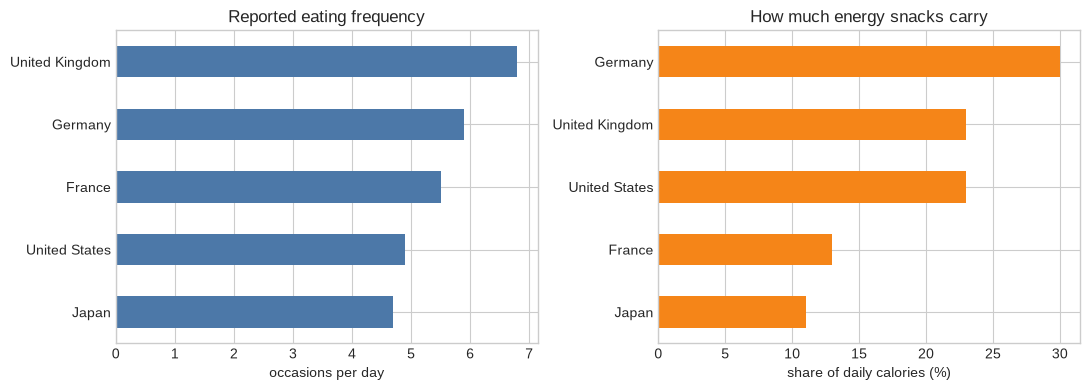

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
patterns["eating occasions per day"].sort_values().plot.barh(ax=axes[0], color="#4c78a8")
patterns["calories from snacks (%)"].sort_values().plot.barh(ax=axes[1], color="#f58518")
axes[0].set(title="Reported eating frequency", xlabel="occasions per day", ylabel="")
axes[1].set(title="How much energy snacks carry", xlabel="share of daily calories (%)", ylabel="")
fig.tight_layout()
plt.show()

Japan and the U.S. are the most useful contrast. Both studies report just under five eating occasions per day, yet snacks provide about **11% of energy in Japan and 23% in the U.S.** Frequency alone misses that difference.

France concentrates more energy in lunch and dinner. Germany and the U.K. report more eating occasions than the U.S., but those occasions include coffee, tea, fruit, bread, and dairy as well as sweets. A snack can be a small addition, a drink, or a fourth meal; counting each as one occasion treats very different habits as equivalent.

Sources: [Murakami et al. on Japan](https://doi.org/10.1017/S1368980020004310), [USDA on U.S. adults](https://www.ncbi.nlm.nih.gov/books/NBK603801/), [Popkin and Duffey on U.S. frequency](https://doi.org/10.3945/ajcn.2009.28962), and the [EPIC ten-country comparison](https://doi.org/10.1017/S1368980016001142). European values are approximate readings from the EPIC country figures; France contains women only.

## 2. What form does the food take?

- **Japan:** three main meals provide about 93% of reported energy when rounded; snacks are usually smaller and commonly include confectionery, fruit, rice crackers, yogurt, or drinks.
- **France:** lunch and dinner remain the centre of the day. Snacks contribute roughly 12–13% of energy and commonly include pastries, fruit, hot drinks, other sweets, and bread.
- **Germany:** eating is more frequent and snacks carry close to 30% of energy in the older EPIC sample. Bread, dairy, fruit, coffee, and sweets can all sit outside the three named meals.
- **United Kingdom:** adults in the general EPIC sample reported nearly seven occasions per day. Snack energy was around the U.S. level, but spread across more occasions.
- **United States:** snacks provide about 23% of daily energy. Sweet bakery products, chips, candy, ice cream, nuts, fruit, and caloric drinks are common; some occasions are large enough to behave like another meal.

This is the middle of the proposed chain: the same increase in frequency can mean a piece of fruit, repeated sweet drinks, or a 300-calorie packaged snack. Only the latter two are likely to add much energy unless the next meal becomes smaller.

## 3. How does that line up with obesity?

WHO age-standardized estimates make the outcome comparable across all five countries. The code selects the latest common year rather than mixing survey years.

In [4]:
obesity_url = "https://ourworldindata.org/grapher/obesity-prevalence-adults-who-gho.csv?v=1&csvType=full&useColumnShortNames=false"
obesity_raw = pd.read_csv(
    obesity_url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
obesity_column = next(column for column in obesity_raw if column.startswith("Obesity among adults"))
common_year = min(
    obesity_raw.loc[obesity_raw["Entity"].eq(country), "Year"].max()
    for country in patterns.index
)
obesity = (
    obesity_raw.loc[
        obesity_raw["Entity"].isin(patterns.index) & obesity_raw["Year"].eq(common_year),
        ["Entity", obesity_column],
    ]
    .set_index("Entity")[obesity_column]
    .rename(f"adult obesity in {common_year} (%)")
)
comparison = patterns.join(obesity)
assert comparison.notna().all().all()
comparison.round(1)

,eating occasions per day,calories from snacks (%),typical pattern,adult obesity in 2024 (%)
country,,,,
Japan,4.7,11,three substantial meals plus small snacks,5.9
United States,4.9,23,snacks often act as an extra meal,41.0
France,5.5,13,meal-centric; snacks are secondary,11.2
Germany,5.9,30,frequent food and drink occasions,20.6
United Kingdom,6.8,23,frequent food and drink occasions,27.4


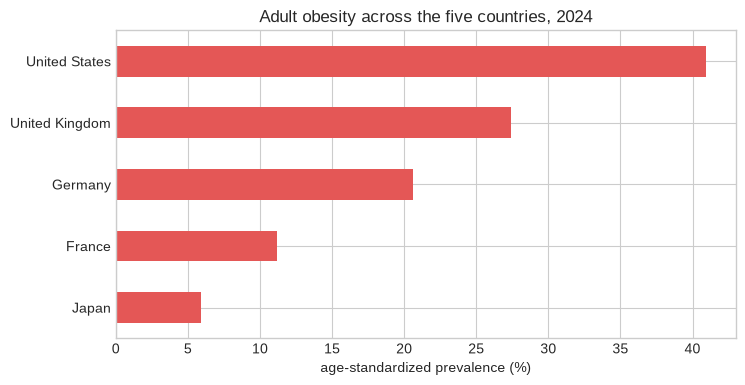

In [5]:
ax = obesity.sort_values().plot.barh(figsize=(8, 4), color="#e45756")
ax.set(title=f"Adult obesity across the five countries, {common_year}", xlabel="age-standardized prevalence (%)", ylabel="")
plt.show()

The countries do **not** form a clean frequency-to-obesity ranking. Japan and the U.S. have similar reported frequency but sit at opposite ends of obesity prevalence. Germany has a larger snack-energy share than the U.S. estimate but substantially less obesity. The U.K. and U.S. have similar snack shares but different obesity rates.

That is not a failure of the proposed chain; it identifies its missing links. For example, EU has much higher physical activity owing to better working hours.

Source: [WHO Global Health Observatory data via Our World in Data](https://ourworldindata.org/grapher/obesity-prevalence-adults-who-gho).

## 4. The U.S. gives the strongest time-order evidence

The cross-country comparison shows why frequency is not sufficient. The U.S. historical record shows how it can still matter.

In [6]:
us_change = pd.DataFrame({
    "measure": ["eating occasions per day", "hours between eating", "adults reporting snacks (%)", "calories from snacks (%)"],
    "1977–78": [3.8, 4.5, 71, 18],
    "2003–06": [4.9, 3.5, 97, 24],
}).set_index("measure")
us_change

,1977–78,2003–06
measure,,
eating occasions per day,3.8,4.9
hours between eating,4.5,3.5
adults reporting snacks (%),71.0,97.0
calories from snacks (%),18.0,24.0


The average U.S. day gained about one eating occasion while the interval between food or caloric drinks fell by about an hour. From 1977 to 1991, larger portions explained most of the rise in reported calories; from the mid-1990s to 2006, more eating occasions explained more of it. Obesity began its steep rise after the late 1970s.

This sequence fits the proposed mechanism: larger meals mattered first, then frequent eating created more opportunities for energy-dense snacks and drinks. It does not show that every snack caused weight gain, and changes in survey methods make the exact calorie increase uncertain.

Sources: [Piernas and Popkin](https://doi.org/10.3945/jn.109.112763), [Duffey and Popkin](https://doi.org/10.1371/journal.pmed.1001050), and [NCHS measured obesity history](https://doi.org/10.15620/cdc/174643).

## 5. What is causal, and what is only suggestive?

Meal-frequency trials find little reliable change in body fat when the same calories are divided among different numbers of meals. Frequency has no strong fattening effect by itself. [A review of 22 trials](https://doi.org/10.1093/advances/nmaa044) supports that narrower conclusion.

Food type can change how much people choose to eat. In a small NIH inpatient crossover trial, adults ate about 500 more calories per day and gained weight on an ultra-processed diet than on a matched unprocessed diet. They also ate faster. The trial did not isolate snacks, but it supports the link between convenient, energy-dense food and passive overconsumption. [Hall et al.](https://doi.org/10.1016/j.cmet.2019.05.008)

So the defensible conclusion is:

**More frequent eating can raise obesity risk when the extra occasions contain substantial calories that are not offset at later meals. Whether a culture calls the occasion a snack matters less than its size, composition, and effect on total intake.**

## Main sources

- Japan meal frequency and energy distribution: [Murakami et al.](https://doi.org/10.1017/S1368980020004310)
- U.S. snack share and foods: [USDA Dietary Data Brief 53](https://www.ncbi.nlm.nih.gov/books/NBK603801/)
- European meal patterns: [EPIC calibration study](https://doi.org/10.1017/S1368980016001142)
- France snack composition: [NutriNet-Santé analysis](https://doi.org/10.1186/s12966-018-0655-7)
- U.S. eating frequency over time: [Popkin and Duffey](https://doi.org/10.3945/ajcn.2009.28962)
- U.S. portions and eating occasions: [Duffey and Popkin](https://doi.org/10.1371/journal.pmed.1001050)
- Comparable obesity estimates: [WHO via Our World in Data](https://ourworldindata.org/grapher/obesity-prevalence-adults-who-gho)